In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:


df = pd.read_csv("../data/dataset.csv")
df.head()


,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [3]:
df.dtypes

Unnamed: 0       int64
open           float64
high           float64
low            float64
close          float64
volume         float64
marketCap      float64
timestamp       object
crypto_name     object
date            object
dtype: object

In [4]:
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [5]:
df.shape


(72946, 10)

In [6]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


In [7]:
df.describe()

,Unnamed: 0,open,high,low,close,volume,marketCap
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


In [8]:
df = df.drop(columns=["Unnamed: 0"])


In [9]:
df = df.sort_values(["crypto_name", "date"])


In [10]:
df.head()

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
44644,0.000000,0.516571,0.000000,0.516571,0.000000,0.000000e+00,2020-10-02T23:59:59.999Z,Aave,2020-10-02
44709,0.523836,65.305938,0.523801,53.151488,0.000000,0.000000e+00,2020-10-03T23:59:59.999Z,Aave,2020-10-03
44780,53.179858,55.070355,50.688990,52.675035,0.000000,0.000000e+00,2020-10-04T23:59:59.999Z,Aave,2020-10-04
44826,52.675035,55.112358,49.787900,53.219243,0.000000,8.912813e+07,2020-10-05T23:59:59.999Z,Aave,2020-10-05
44843,53.291969,53.402270,40.734578,42.401599,583091.459763,7.101144e+07,2020-10-06T23:59:59.999Z,Aave,2020-10-06


In [11]:
df["crypto_name"].nunique()


56

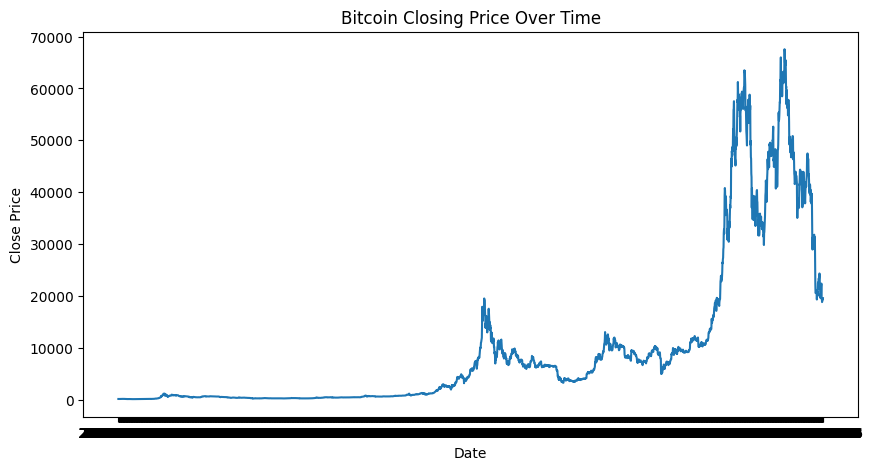

In [12]:
btc = df[df["crypto_name"] == "Bitcoin"]

plt.figure(figsize=(10,5))
plt.plot(btc["date"], btc["close"])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()


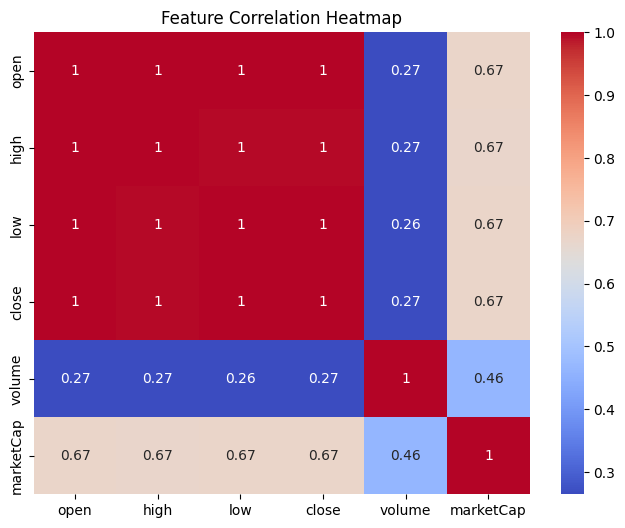

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["open","high","low","close","volume","marketCap"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()


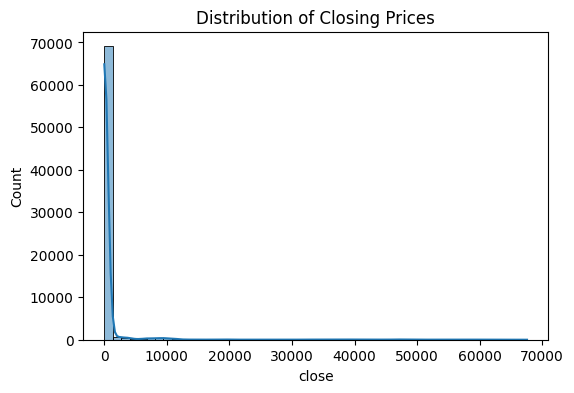

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df["close"], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.show()


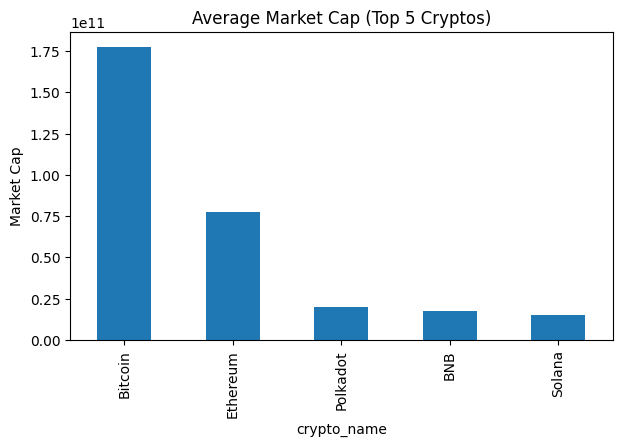

In [15]:
top_coins = df.groupby("crypto_name")["marketCap"].mean().sort_values(ascending=False).head(5)

top_coins.plot(kind="bar", figsize=(7,4), title="Average Market Cap (Top 5 Cryptos)")
plt.ylabel("Market Cap")
plt.show()


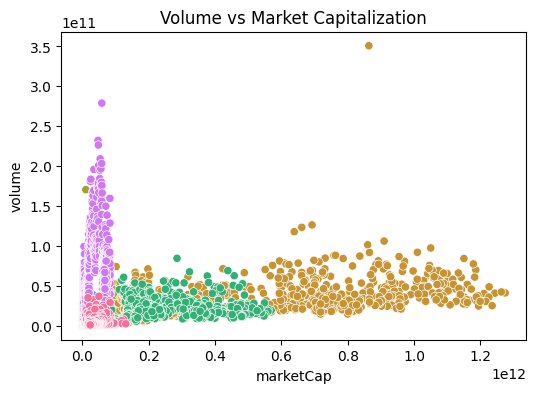

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="marketCap", y="volume", hue="crypto_name", legend=False)
plt.title("Volume vs Market Capitalization")
plt.show()


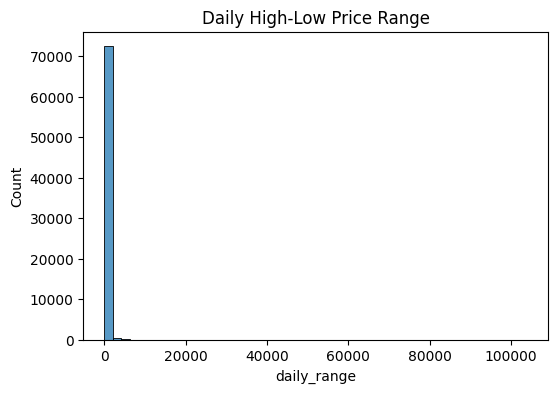

In [17]:
df["daily_range"] = df["high"] - df["low"]

plt.figure(figsize=(6,4))
sns.histplot(df["daily_range"], bins=50)
plt.title("Daily High-Low Price Range")
plt.show()


In [18]:

corr = df[[
    "open", "high", "low", "close",
    "volume", "marketCap"
]].corr()

corr


,open,high,low,close,volume,marketCap
open,1.000000,0.997202,0.999396,0.999227,0.266756,0.670421
high,0.997202,1.000000,0.996678,0.996989,0.266207,0.667033
low,0.999396,0.996678,1.000000,0.999572,0.264726,0.670297
close,0.999227,0.996989,0.999572,1.000000,0.266575,0.670958
volume,0.266756,0.266207,0.264726,0.266575,1.000000,0.463637
marketCap,0.670421,0.667033,0.670297,0.670958,0.463637,1.000000


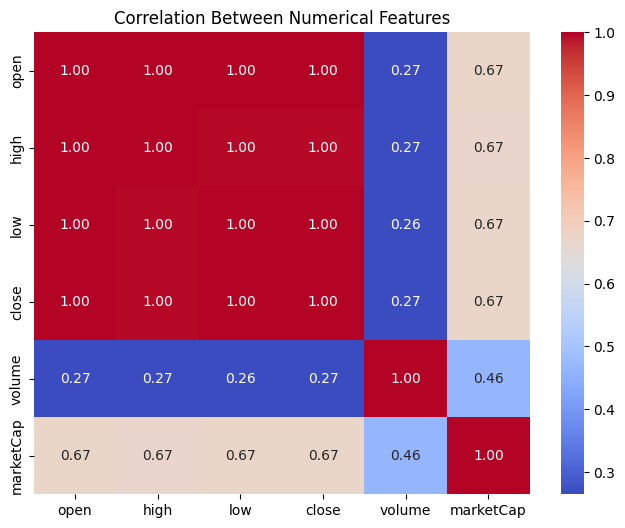

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Numerical Features")
plt.show()


### Correlation Analysis

- Open, high, low, and close prices show strong positive correlation.
- Volume and market capitalization exhibit weaker correlation with prices.
- High correlation among OHLC features indicates multicollinearity.


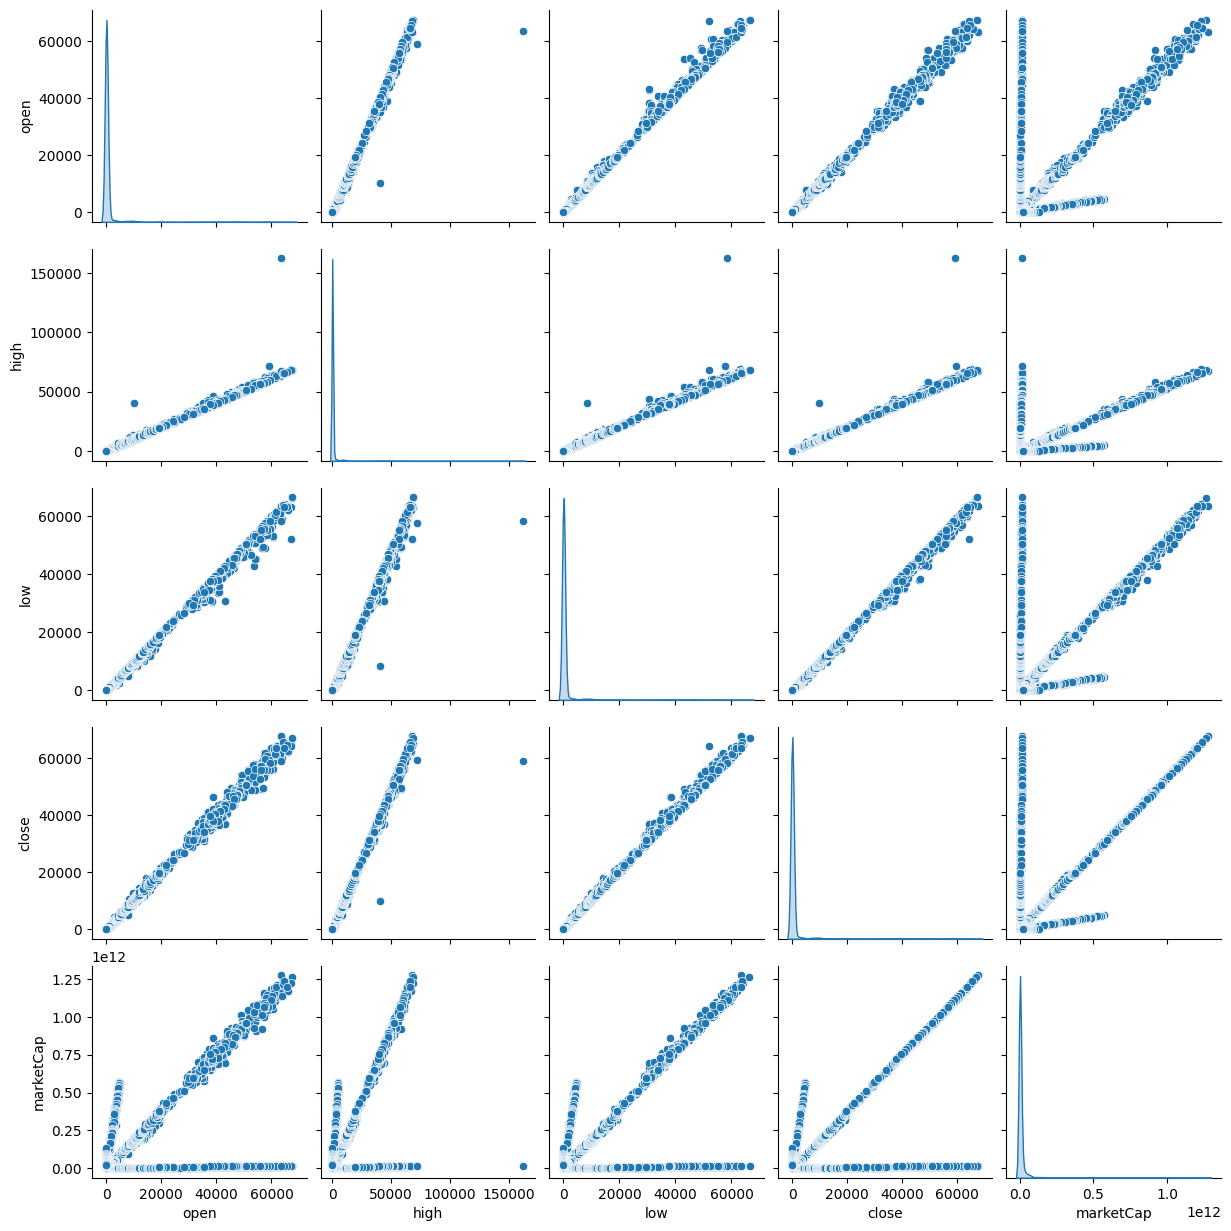

In [20]:
sns.pairplot(
    df[["open","high","low","close","marketCap"]],
    diag_kind="kde"
)
plt.show()


## 📌 Key EDA Observations

- **Bitcoin has significantly higher prices and market capitalization** compared to other cryptocurrencies.
- **Volume values are zero for early periods**, indicating limited trading activity or missing records.
- **Strong correlation exists between open, high, low, and close prices**, suggesting high multicollinearity.
- **Daily price ranges vary significantly**, indicating periods of high volatility.
- **Market capitalization and volume together provide insights into liquidity and market stability.**
